In [1]:
import model as m
from tensorflow.keras.models import load_model
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
import Evaluate_results as er
import matplotlib.pyplot as plt
import seaborn as sns
from keras import backend as K
import tensorflow as tf
import tensorflow as tf
import os
import json
from contextlib import redirect_stdout
import yaml
from matplotlib.colors import ListedColormap
from sklearn.manifold import TSNE
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

2024-04-16 18:45:39.969963: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-04-16 18:45:39.972672: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-04-16 18:45:39.998862: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-16 18:45:39.998886: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-16 18:45:39.999633: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [2]:
dataset_path = 'Data/RNAseq_All_abundances_adjusted.csv'
loss = "Poisson"
optimizer = "adam"
metrics = ["mae"]
epochs = 1500
batch_size = 512
validation_split = 0.2
lasso_alpha = 0.01
two_step_normalization = True


In [13]:
def create_new_folder(base_path="Results"):
    # Check if the Results directory exists, if not, create it
    results_dir = os.path.join(base_path, "Model_outputs")
    if not os.path.exists(results_dir):
        os.makedirs(results_dir)

    # Find existing result folders and determine the next number
    existing_folders = [name for name in os.listdir(results_dir) if os.path.isdir(os.path.join(results_dir, name)) and "result_standar_rnaSeq" in name]
    if not existing_folders:
        next_number = 1
    else:
        # Sort existing folders to get the highest numbered folder
        existing_folders.sort()
        last_folder = existing_folders[-1]
        last_number = int(last_folder.replace("result_standar_rnaSeq", ""))
        next_number = last_number + 1

    # Generate the name for the new folder
    new_folder_name = "result_standar_rnaSeq{:02d}".format(next_number)
    new_folder_path = os.path.join(results_dir, new_folder_name)

    # Create the new folder
    os.makedirs(new_folder_path)

    return new_folder_path

In [4]:
def plot_distrobution_features(expression_df, age:list, n_features=None):
    def map_age(age):
        if age == 35:
            return 'Y'
        elif age > 65:
            return 'O'
        else:
            return 'M'
    x = expression_df
    if n_features:
        x=x.sample(n=n_features, axis='columns')
    x["Age"] = age.apply(lambda age: map_age(age))
    data = x
    melted_data = pd.melt(data,id_vars="Age",
                    var_name="features",
                    value_name='value')

    plt.figure(figsize=(10,10))
    sns.violinplot(x="features", y="value", hue="Age", data=melted_data,split=True, inner="quart")
    plt.xticks(rotation=90)


    #sns.boxplot(x="features", y="value", hue="Age", data=melted_data, showfliers=False)
    #plt.xticks(rotation=90)
    return melted_data


In [5]:
def map_to_category(age):
    if age < 35:
        return "Young"
    elif age > 65:
        return "Old"
    else:
        return "MiddleAge"

In [6]:
def color_feature_selction_TSNE(df):
    """
    make sure df has the expression and the column Age
    """
    feature_df = pd.DataFrame(df)
    feature_df_t = pd.DataFrame(df) 
    feature_df_t["Age"]=  [map_to_category(age) for age in df["Age"]] 
    tab20_colors = plt.cm.tab10.colors
    num_colors = len(np.unique(feature_df_t["Age"]))
    colors = [tab20_colors[i] for i in range(num_colors)]
    custom_cmap = ListedColormap(colors)
    ategory_map = {category: i for i, category in enumerate(feature_df_t["Age"])}
    category_map = {'Young': -1, 'MiddleAge': 0, 'Old': 1}
    numeric_age_order = [category_map[experiment] for experiment in feature_df_t["Age"]]
    X = feature_df.drop(columns=["Age"]).values 
    tSNE=TSNE(n_components=2)
    tSNE_result=tSNE.fit_transform(X)
    # Step 3: Visualize the clusters
    # Plot the first two principal components and color them according to the assigned clusters
    x=tSNE_result[:,0]
    y=tSNE_result[:,1]

    plt.figure(figsize=(8, 6))
    plt.scatter(x,y, c=numeric_age_order, cmap=custom_cmap, s=50, alpha=0.5)
    plt.title('TSNE Adjusted')
    #plt.colorbar(label="Experiment", spacing ="uniform",  values=numeric_experiment_order)

    # Create legend with experiment names
    legend_handles = [plt.Line2D([0], [0], marker='o',  markerfacecolor=color, markersize=10, label=f'Experiment {i+1}') for i, color in enumerate(colors)]
    plt.legend(handles=legend_handles, labels=list(category_map.keys()), loc='best')

    #plt.legend(list(category_map.keys()))
    #plt.show()

    plt.savefig(f"{m.output_directory}/TSNE_Scatter_Plot_feature_selection.jpg")

In [7]:
def save_performance_results(results, my_model):
    def analyze_restults(results, my_model):
        results["Experiment"] = my_model.z_test["Experiment"].values
        results["Sample"] = my_model.z_test["Sample"].values
        #results["Sex"] = my_model.z_test["Sex"].values
        #results["Status"] = my_model.z_test["Status"].values

        results["absolute_error"] = abs(results["Actual"]-results["Predicted"])
        results["big_absolute_error"] = np.where(results["absolute_error"] < 5, 0, results["absolute_error"])
        return results

    results = analyze_restults(results, my_model)
    with open(f"{m.output_directory}/model_summary.txt", "a") as f:
        # Redirect the stdout to the file
        with redirect_stdout(f):
            print("/n/t Actual age distribution:")
            print(results["Actual"].describe())
            print("/n/t Predicted age distribution:")
            print(results["Predicted"].describe())
            print("/n/t Predicted absolute error distribution:")
            print(results["absolute_error"].describe())
            print("/n/n/t /t Is the experiment acting the outcome?/n")
            
            print("/n/t Error distribution absolute_error ~ Experiment anova_lm:")
            print(er.evaluate_error_experiment(results))
            print("/n/t Krustal Wallis test:")
            print (er.evaluate_Kruskal_Wallis(results))
            print("/n/t Dunnes test:")
            print(er.evaluate_Dunnes_test(results))
    er.plot_Dunes_result(er.evaluate_Dunnes_test(results), save=True, file_name=f"{m.output_directory}/Dunnes_test.png")


In [8]:
def run_all():

    m.output_directory=create_new_folder()
    training_data=pd.read_csv(dataset_path)
    my_model = m.Model(training_data)
    normalized_X_train, normalized_X_test_fs = my_model.prepare_data(df=training_data, lasso_alpha=lasso_alpha, two_step=two_step_normalization)
    my_model.train(normalize_X_train=normalized_X_train, 
                    epochs=epochs, optimizer=optimizer,
                    loss=loss, metrics=metrics, batch_size=batch_size, validation_split=validation_split)
    m.plot_model(my_model.model, f'{m.output_directory}/model.png', show_shapes=True)
    results, error = my_model.test(normalized_X_test_fs, my_model.y_test)
    m.print_performance(my_model.history, results, my_model.z_test, save=True)

    conf_dic = {'dataset':dataset_path,
                'loss': loss,
                'optimizer': optimizer,
                'metrics': metrics,
                'epochs': epochs, 
                'batch_size': batch_size, 
                'validation_split': validation_split, 
                'lasso_alpha': lasso_alpha, 
                'two_step_normalization': two_step_normalization}
    with open(f"{m.output_directory}/model_summary.txt", "a") as f:
        # Redirect the stdout to the file
        with redirect_stdout(f):
            print("Error: ")
            print(error)

    save_performance_results(results, my_model)
    clean_df_z = pd.DataFrame(my_model.z_test.values)
    clean_df_z.columns = my_model.z_test.columns
    results_all_metadata = pd.concat([results,clean_df_z ], axis=1)
    with open(f"{m.output_directory}/configuration.yaml", "w") as yaml_file:
        yaml.dump(conf_dic, yaml_file, default_flow_style=False)
    with open(f"{m.output_directory}/model_architecture.yaml", "w") as yaml_file:
        yaml.dump(json.loads(my_model.model.to_json()), yaml_file, default_flow_style=False)
    with open(f"{m.output_directory}/selected_features.csv", "w") as f:
        f.write("\n".join(list(my_model.model_in_features)))

    feature_df = pd.DataFrame(normalized_X_train)
    feature_df = feature_df.dropna()
    feature_df
    feature_df["Age"]= my_model.y_train.values
    color_feature_selction_TSNE(feature_df)
    # Now check with the training data
        
        



In [9]:
#run_all()

In [10]:

def my_train_data(X_train, y_train, optimizer='adam', loss='mse', metrics=['mae'], epochs=1500, validation_split=0.1,
              batch_size=50):
    """
    Train the data
    
    :return: The trained model
    """

    n_features = X_train.shape[1]
    new_model = Sequential()

    # Add layers to the model 
    new_model.add(Dense(8, activation='relu', kernel_initializer='he_normal', input_shape=(n_features,)))
    new_model.add(Dense(16, activation='relu', kernel_initializer='he_normal', input_shape=(n_features,)))
    new_model.add(Dropout(0.5))  # Adding dropout to reduce overfitting
    new_model.add(Dense(32, activation='relu', kernel_initializer='he_normal'))
    new_model.add(Dropout(0.5))  # Adding dropout to reduce overfitting
    new_model.add(Dense(64, activation='softsign', kernel_initializer='he_normal'))
    new_model.add(Dense(32, activation='relu', kernel_initializer='he_normal'))
    new_model.add(Dropout(0.5))  # Adding dropout to reduce overfitting
    new_model.add(Dense(16, activation='relu', kernel_initializer='he_normal'))
    new_model.add(Dropout(0.5))
    new_model.add(Dense(8, activation='relu', kernel_initializer='he_normal', input_shape=(n_features,)))
    new_model.add(Dense(1))

    # Compile the model
    new_model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    new_model_history = new_model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0, validation_split=validation_split)
    return new_model, new_model_history
m.train_data=my_train_data

In [11]:
dataset_path = 'Data/RNAseq_All_abundances_adjusted.csv'
loss = "mse"
optimizer = "adamW"
metrics = ["mae"]
epochs = 1000
batch_size = 50
validation_split = 0.2
lasso_alpha = 0.005
two_step_normalization = False
    

In [14]:

m.output_directory=create_new_folder()
training_data=pd.read_csv(dataset_path)

In [35]:
metadata = pd.read_csv("Data/All_rna_samples_metadata.csv")

In [36]:
exp_GSE60590=metadata[metadata["Experiment"] == "GSE60590"]
exp_GSE152558=metadata[metadata["Experiment"] == "GSE152558"]
exp_GSE164471=metadata[metadata["Experiment"] == "GSE164471"]
exp_GSE157585=metadata[metadata["Experiment"] == "GSE157585"]
exp_GSE167186=metadata[metadata["Experiment"] == "GSE167186"]



In [38]:
metadata["Sex"]

0         NaN
1        male
2        male
3         NaN
4         NaN
        ...  
323      male
324      male
325      male
326      male
327    female
Name: Sex, Length: 328, dtype: object

In [31]:
exp= exp_GSE167186
len(exp[(exp["Age"]<=35)]), len(exp[(exp["Age"]>35)&(exp["Age"]<65)]), len(exp[(exp["Age"]>65)])

(19, 3, 51)

In [39]:
exp= exp_GSE152558
len(exp[(exp["Sex"]=="female")]), len(exp[(exp["Sex"]=="male")])

(3, 2)

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.588e+02, tolerance: 8.649e+00
  model = cd_fast.enet_coordinate_descent(
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:85: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MAE: 25.379
Loss: 898.033
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


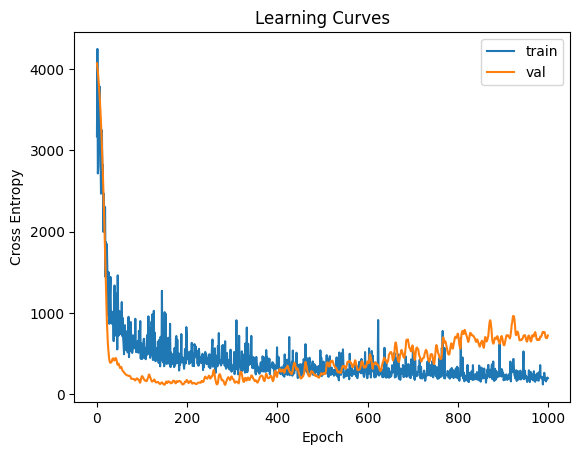

    Actual  Predicted Experiment
0     24.0  17.100252  GSE157585
1     52.0  40.347797  GSE129643
2     27.0  17.100252  GSE167186
3     51.0  31.666862  GSE129643
4     24.0  17.100252  GSE157585
5     77.0  40.801590  GSE167186
6     78.0  34.572357  GSE167186
7     81.0  43.439487  GSE129643
8     38.0  18.665394  GSE164471
9     52.0  35.661465  GSE164471
10    73.0  33.813545  GSE167186
11    71.0  43.473404  GSE157585
12    52.0  41.113598  GSE164471
13    38.0  40.313931  GSE164471
14    71.0  41.728367  GSE157585
15    25.0  35.728176  GSE167186
16    71.0  43.246979  GSE157585
17    85.0  36.553383  GSE152558
18    31.0  30.323360  GSE164471
19    71.0  42.334808  GSE157585
20    77.9  43.332714  GSE167186
21    24.0  17.164097  GSE157585
22    84.0  21.417244  GSE167186
23    71.0  24.988930  GSE157585
24    19.0  17.100252  GSE167186
25    24.0  17.100252  GSE157585
26    26.0  17.198809  GSE164471
27    86.0  40.645874  GSE167186
28    71.0  43.577343  GSE157585
29    73.0

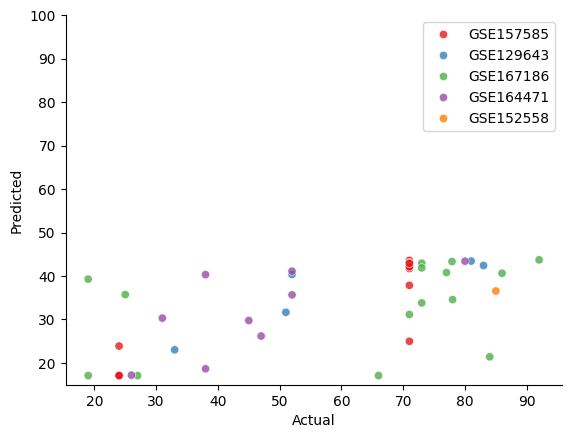

Experiment
GSE157585     18
GSE167186     15
GSE164471      9
GSE129643      5
GSE152558      1
Name: count, dtype: int64
mae: 25.379217950503033, mse: 869.7132022069039, min: 17.100252151489258, max: 43.72013854980469


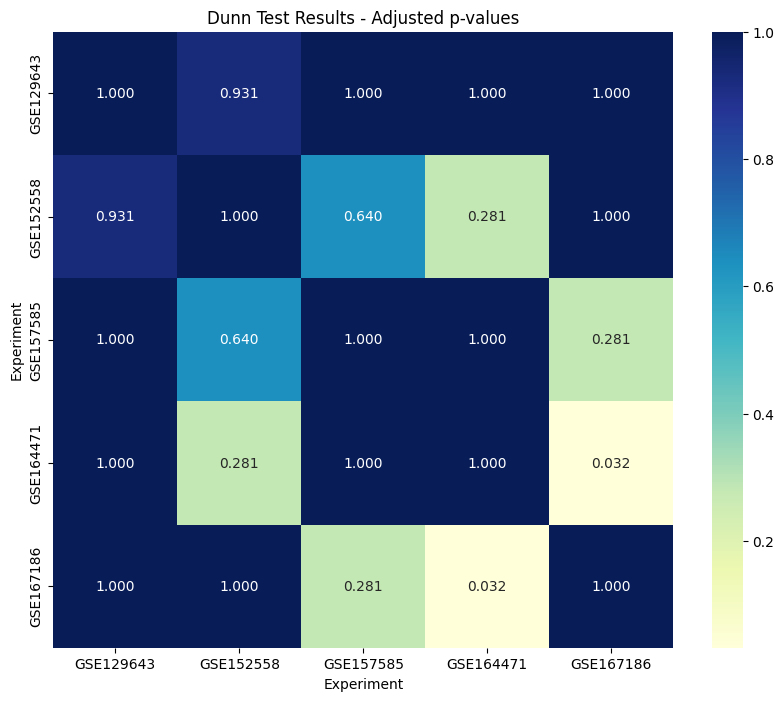

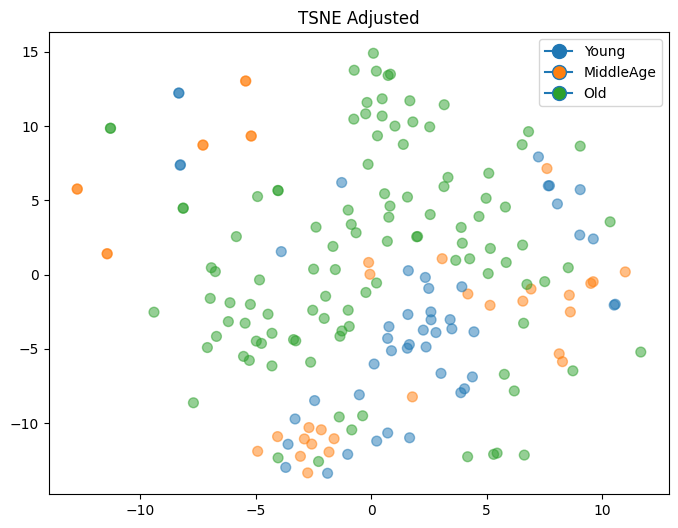

In [57]:

my_model = m.Model(training_data)
normalized_X_train, normalized_X_test_fs = my_model.prepare_data(df=training_data, lasso_alpha=lasso_alpha, two_step=two_step_normalization)
my_model.train(normalize_X_train=normalized_X_train, 
                epochs=epochs, optimizer=optimizer,
                loss=loss, metrics=metrics, batch_size=batch_size, validation_split=validation_split)
m.plot_model(my_model.model, f'{m.output_directory}/model.png', show_shapes=True)
results, error = my_model.test(normalized_X_test_fs, my_model.y_test)
m.print_performance(my_model.history, results, my_model.z_test, save=True)

conf_dic = {'dataset':dataset_path,
            'loss': loss,
            'optimizer': optimizer,
            'metrics': metrics,
            'epochs': epochs, 
            'batch_size': batch_size, 
            'validation_split': validation_split, 
            'lasso_alpha': lasso_alpha, 
            'two_step_normalization': two_step_normalization}
with open(f"{m.output_directory}/model_summary.txt", "a") as f:
    # Redirect the stdout to the file
    with redirect_stdout(f):
        print("Error: ")
        print(error)

save_performance_results(results, my_model)
clean_df_z = pd.DataFrame(my_model.z_test.values)
clean_df_z.columns = my_model.z_test.columns
results_all_metadata = pd.concat([results,clean_df_z ], axis=1)
results_all_metadata.to_csv(f"{m.output_directory}/results_all_metadata.csv")
with open(f"{m.output_directory}/configuration.yaml", "w") as yaml_file:
    yaml.dump(conf_dic, yaml_file, default_flow_style=False)
with open(f"{m.output_directory}/model_architecture.yaml", "w") as yaml_file:
    yaml.dump(json.loads(my_model.model.to_json()), yaml_file, default_flow_style=False)
with open(f"{m.output_directory}/selected_features.csv", "w") as f:
    f.write("\n".join(list(my_model.model_in_features)))

feature_df = pd.DataFrame(normalized_X_train)
feature_df = feature_df.dropna()
feature_df
feature_df["Age"]= my_model.y_train.values
color_feature_selction_TSNE(feature_df)

In [34]:
small = training_data[['Age', "Sample", "Experiment"]]
small = small[small["Experiment"] == "GSE60590"]
small.shape

(31, 3)

Running the Violins of the features already selected

,Age,features,value
0,O,ENSG00000005156.11,0.748252
1,O,ENSG00000005156.11,3.137715
2,O,ENSG00000005156.11,0.894032
3,M,ENSG00000005156.11,0.119874
4,O,ENSG00000005156.11,0.199723
...,...,...,...
3235,O,ENSG00000061936.9,0.251151
3236,M,ENSG00000061936.9,-0.431103
3237,O,ENSG00000061936.9,0.089763
3238,O,ENSG00000061936.9,-0.492225


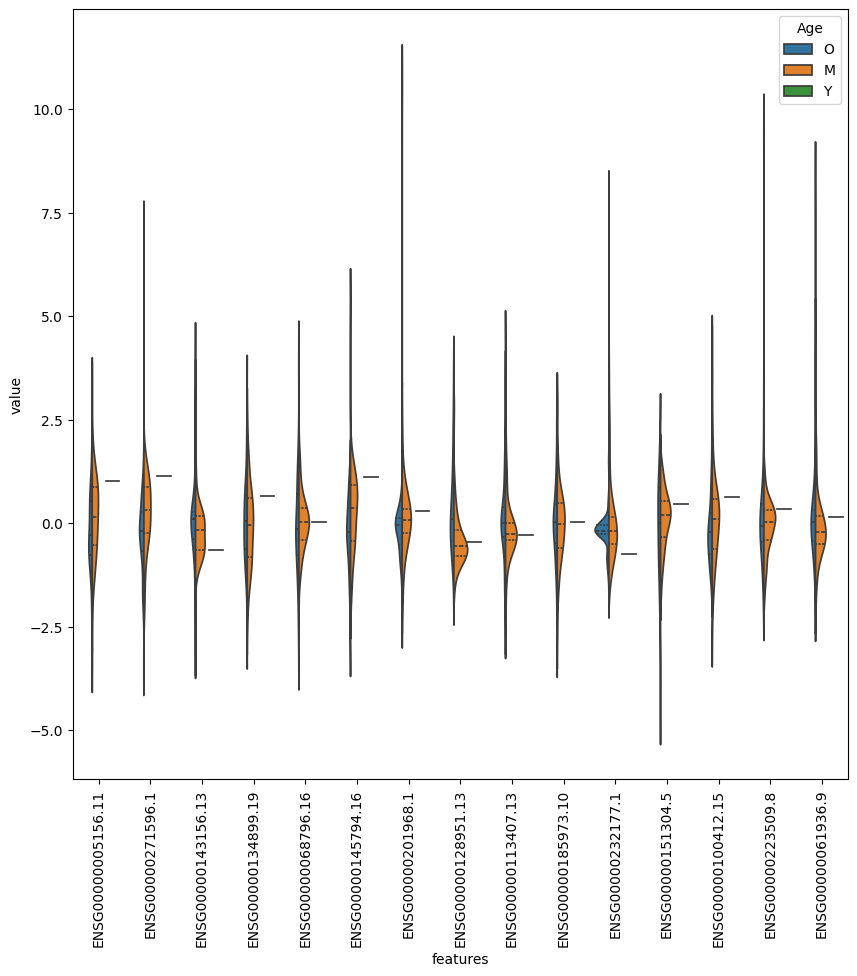

In [21]:
feature_df= pd.DataFrame(normalized_X_train, columns=my_model.model_in_features)
age_df = pd.Series( my_model.y_train.values)
md = plot_distrobution_features(expression_df=feature_df, age=age_df, n_features=15)
md

In [ ]:
my_model.y_train


Running the violins on random features

,Age,features,value
0,M,ENSG00000171987.1,0.781005
1,M,ENSG00000171987.1,1.313454
2,O,ENSG00000171987.1,-1.082366
3,M,ENSG00000171987.1,1.176260
4,O,ENSG00000171987.1,0.096709
...,...,...,...
3235,O,ENSG00000223718.3,1.415244
3236,O,ENSG00000223718.3,-0.189538
3237,O,ENSG00000223718.3,-0.142042
3238,NaN,ENSG00000223718.3,-0.715190


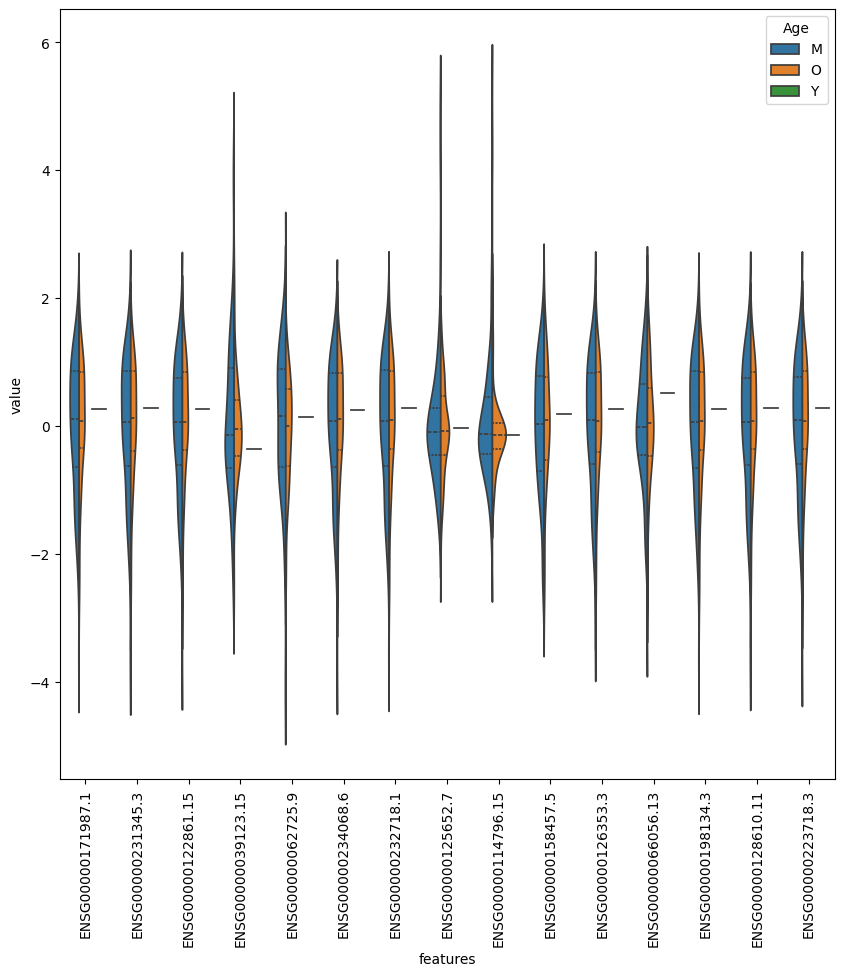

In [22]:
feature_df = pd.DataFrame(my_model.X_train)
age_df = pd.Series( my_model.y_train.values)
md= plot_distrobution_features(expression_df=feature_df, age=age_df, n_features=15)
md

In [ ]:
type(my_model.y_train)


In [ ]:
feature_df= pd.DataFrame(normalized_X_train, columns=my_model.model_in_features)
age_df = pd.Series( my_model.y_train.values)
md = plot_distrobution_features(expression_df=feature_df, age=age_df, n_features=5)
md

In [ ]:
feature_df = pd.DataFrame(my_model.X_train)
age_df = pd.Series( my_model.y_train.values)
md= plot_distrobution_features(expression_df=feature_df, age=age_df, n_features=5)
md

Lets try with clusters; TSNE

In [ ]:
feature_df = pd.DataFrame(my_model.X_train)
feature_df["Age"]= my_model.y_train.values
color_feature_selction_TSNE(feature_df)

In [ ]:


feature_df = pd.DataFrame(normalized_X_train)
feature_df = feature_df.dropna()
feature_df
feature_df["Age"]= my_model.y_train.values
color_feature_selction_TSNE(feature_df)

In [ ]:
feature_df = pd.DataFrame(training_data)
feature_df = feature_df.drop(columns=['Experiment', 'Sample'])
color_feature_selction_TSNE(feature_df)

In [ ]:
training_data.columns

Using random forest instead

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

def my_evaluate_model(model, X_test, y_test):
    """
    Evaluate the model
    
    :param model: The trained model to evaluate
    :param X_test: The test data
    :param y_test: The test labels
    """
    # Make predictions using the trained model
    predictions = model.predict(X_test)

    # Calculate mean absolute error (MAE)
    mae = mean_absolute_error(y_test, predictions)
    print('MAE: %.3f' % mae)

    # Create a DataFrame to display actual vs predicted values
    results = pd.DataFrame({'Actual': y_test, 'Predicted': predictions})

    return results
m.evaluate_model=my_evaluate_model

In [ ]:

def my_train_data(X_train, y_train, n_estimators=500, max_depth=None, min_samples_split=10, min_samples_leaf=20,
                  bootstrap=True):
    """
    Train the data using Random Forest Regressor
    
    :return: The trained model
    """

    # Initialize Random Forest Regressor
    rf_model = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth,
                                      min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf,
                                      bootstrap=bootstrap)

    # Fit the model
    rf_model.fit(X_train, y_train)

    return rf_model



In [ ]:
m.train_data=my_train_data
m.output_directory=create_new_folder()
training_data=pd.read_csv(dataset_path)
my_model = m.Model(training_data)
normalized_X_train, normalized_X_test_fs = my_model.prepare_data(df=training_data, lasso_alpha=lasso_alpha, two_step=two_step_normalization)

my_model.model = m.train_data(X_train=normalized_X_train, y_train=my_model.y_train, n_estimators=400, max_depth=None, min_samples_split=20, min_samples_leaf=20,
                  bootstrap=True)

results = m.evaluate_model(my_model.model, normalized_X_test_fs, my_model.y_test)

m.plot_results(results, my_model.z_test, save=True)

conf_dic = {'dataset':dataset_path,
            'loss': loss,
            'optimizer': optimizer,
            'metrics': metrics,
            'epochs': epochs, 
            'batch_size': batch_size, 
            'validation_split': validation_split, 
            'lasso_alpha': lasso_alpha, 
            'two_step_normalization': two_step_normalization}


save_performance_results(results, my_model)
clean_df_z = pd.DataFrame(my_model.z_test.values)
clean_df_z.columns = my_model.z_test.columns
results_all_metadata = pd.concat([results,clean_df_z ], axis=1)
results_all_metadata.to_csv(f"{m.output_directory}/results_all_metadata.csv")
with open(f"{m.output_directory}/configuration.yaml", "w") as yaml_file:
    yaml.dump(conf_dic, yaml_file, default_flow_style=False)
with open(f"{m.output_directory}/model_architecture.yaml", "w") as yaml_file:
    for param_name, param_value in my_model.model.get_params().items():
            yaml_file.write(f"{param_name}: {param_value}\n")
with open(f"{m.output_directory}/selected_features.csv", "w") as f:
    f.write("\n".join(list(my_model.model_in_features)))

feature_df = pd.DataFrame(normalized_X_train)
feature_df = feature_df.dropna()
feature_df
feature_df["Age"]= my_model.y_train.values
color_feature_selction_TSNE(feature_df)


In [ ]:
lasso_alpha = 0.9
m.train_data=my_train_data
m.output_directory=create_new_folder()
training_data=pd.read_csv(dataset_path)
my_model = m.Model(training_data)
normalized_X_train, normalized_X_test_fs = my_model.prepare_data(df=training_data, lasso_alpha=lasso_alpha, two_step=two_step_normalization)


feature_df = pd.DataFrame(normalized_X_train)
feature_df = feature_df.dropna()
feature_df
feature_df["Age"]= my_model.y_train.values
color_feature_selction_TSNE(feature_df)


In [ ]:


lasso_alpha

In [ ]:

results

In [ ]:
#m.print_performance(my_model.history, results, my_model.z_test, save=True)
